# Neural Machine Translation Sequence-to-Sequence (NMT Seq2Seq) Model: Version 1
## Myanmar (Burmese) Language: Grapheme to Phoneme Translation

## Setup

In [1]:
!marian --help

Marian: Fast Neural Machine Translation in C++
Usage: marian [OPTIONS]

General options:
  -h,--help                             Print this help message and exit
  --version                             Print the version number and exit
  --authors                             Print list of authors and exit
  --cite                                Print citation and exit
  --build-info TEXT                     Print CMake build options and exit. Set to 'all' to print advanced options
  -c,--config VECTOR ...                Configuration file(s). If multiple, later overrides earlier
  -w,--workspace INT=2048               Preallocate arg MB of work space. Negative `--workspace -N` value allocates workspace as total available GPU memory minus N megabytes.
  --log TEXT                            Log training process information to file given by arg
  --log-level TEXT=info                 Set verbosity level of logging: trace, debug, info, warn, err(or), critical, off
  --log-time-zone TEXT  

In [2]:
from pathlib import Path
from IPython.display import Image

In [3]:
ROOT = Path("..").resolve()

DATA_ROOT = ROOT / "data"
DATA_DIR = DATA_ROOT / "cleaned"
VOCAB_DIR = DATA_ROOT / "vocab"
MODEL_DIR = ROOT / "models"

BLEU_DIR = "/home/lawun330/NLP/ubuntu-17.04/moses/scripts/generic"

## Configurations

File paths must be updated in a bash file.

In [4]:
!find {ROOT}/*.sh

/home/lawun330/Desktop/basic-neural-machine-translation/seq2seq.myph.sh


In [5]:
!cat {ROOT}/seq2seq.myph.sh

#!/bin/bash

## Written by Ye Kyaw Thu, Affiliated Professor, CADT, Cambodia
## for NMT Experiments between Burmese and Ethnic Languages
## used Marian NMT Framework for seq2seq training
## Last updated: 23 May 2022

## Reference: https://marian-nmt.github.io/examples/mtm2017/complex/

model_folder="../models/model.seq2seq.myph"; # -- MODIFIED --
mkdir ${model_folder};
data_path="../data/cleaned"; # -- MODIFIED --
vocab_path="../data/vocab"; # -- MODIFIED --
src="my"; tgt="ph"; # -- MODIFIED --

marian \
  --type s2s \
  --train-sets ${data_path}/train.${src} ${data_path}/train.${tgt} \
  --max-length 200 \
  --valid-sets ${data_path}/dev.${src} ${data_path}/dev.${tgt} \
  --vocabs  ${vocab_path}/vocab.${src}.yml  ${vocab_path}/vocab.${tgt}.yml \
  --model ${model_folder}/model.npz \
  --workspace 500 \
  --enc-depth 2 --enc-type alternating --enc-cell lstm --enc-cell-depth 2 \
  --dec-depth 2 --dec-cell lstm --dec-cell-base-depth 2 --dec-cell-high-depth 2 \
  --tied-embeddings --layer

## Machine Translation: Seq2Seq Training for Grapheme to Phoneme

In [6]:
!{ROOT}/seq2seq.myph.sh

mkdir: cannot create directory ‘../models/model.seq2seq.myph’: File exists
[2026-05-28 20:57:09] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-05-28 20:57:09] [marian] Running on ROG-Strix-Hero-II as process 32514 with command line:
[2026-05-28 20:57:09] [marian] marian -c ../models/model.seq2seq.myph/config.yml
[2026-05-28 20:57:09] [config] after: 0e
[2026-05-28 20:57:09] [config] after-batches: 0
[2026-05-28 20:57:09] [config] after-epochs: 0
[2026-05-28 20:57:09] [config] all-caps-every: 0
[2026-05-28 20:57:09] [config] allow-unk: false
[2026-05-28 20:57:09] [config] authors: false
[2026-05-28 20:57:09] [config] beam-size: 12
[2026-05-28 20:57:09] [config] bert-class-symbol: "[CLS]"
[2026-05-28 20:57:09] [config] bert-mask-symbol: "[MASK]"
[2026-05-28 20:57:09] [config] bert-masking-fraction: 0.15
[2026-05-28 20:57:09] [config] bert-sep-symbol: "[SEP]"
[2026-05-28 20:57:09] [config] bert-train-type-embeddings: true
[2026-05-28 20:57:09] [config] bert-type-vocab-s

## Results: Config File

In [7]:
!cat {MODEL_DIR}/model.seq2seq.myph/config.yml

# Marian configuration file generated at 2026-05-28 20:57:09 +0700 with version v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
# General options
authors: false
cite: false
build-info: ""
workspace: 500
log: ../models/model.seq2seq.myph/train.log
log-level: info
log-time-zone: ""
quiet: false
quiet-translation: false
seed: 1111
check-nan: false
interpolate-env-vars: false
relative-paths: false
sigterm: save-and-exit
# Model options
model: ../models/model.seq2seq.myph/model.npz
pretrained-model: ""
ignore-model-config: false
type: s2s
dim-vocabs:
  - 0
  - 0
dim-emb: 512
factors-dim-emb: 0
factors-combine: sum
lemma-dependency: ""
lemma-dim-emb: 0
dim-rnn: 1024
enc-type: alternating
enc-cell: lstm
enc-cell-depth: 2
enc-depth: 2
dec-cell: lstm
dec-cell-base-depth: 2
dec-cell-high-depth: 2
dec-depth: 2
skip: true
layer-normalization: true
right-left: false
input-types:
  []
best-deep: false
tied-embeddings: true
tied-embeddings-src: false
tied-embeddings-all: false
output-omit-bias: false
tran

## Results: Output Models

In [8]:
# check available models
!ls {MODEL_DIR}/model.seq2seq.myph/ --color=auto

config.yml           model.iter40000.npz    model.npz.optimizer.npz
model.iter10000.npz  model.iter45000.npz    model.npz.progress.yml
model.iter15000.npz  model.iter50000.npz    model.npz.yml
model.iter20000.npz  model.iter5000.npz     s2s.my-ph.log
model.iter25000.npz  model.iter55000.npz    train.log
model.iter30000.npz  model.npz              valid.log
model.iter35000.npz  model.npz.decoder.yml


In [9]:
# check best model
!cat {MODEL_DIR}/model.seq2seq.myph/valid.log

[2026-05-28 21:20:59] [valid] Ep. 14 : Up. 5000 : cross-entropy : 1.69946 : new best
[2026-05-28 21:21:01] [valid] Ep. 14 : Up. 5000 : perplexity : 1.55598 : new best
[2026-05-28 21:21:01] [valid] First sentence's tokens as scored:
[2026-05-28 21:21:01] [valid] DefaultVocab keeps original segments for scoring
[2026-05-28 21:21:01] [valid]   Hyp: ou' ta- ra- hpa- la. gu. ni
[2026-05-28 21:21:01] [valid]   Ref: ou' ta- ra. hpa- la. gu. ni
[2026-05-28 21:21:04] [valid] Ep. 14 : Up. 5000 : bleu : 68.5179 : new best
[2026-05-28 21:42:22] [valid] Ep. 28 : Up. 10000 : cross-entropy : 1.71673 : stalled 1 times (last best: 1.69946)
[2026-05-28 21:42:23] [valid] Ep. 28 : Up. 10000 : perplexity : 1.56299 : stalled 1 times (last best: 1.55598)
[2026-05-28 21:42:27] [valid] Ep. 28 : Up. 10000 : bleu : 69.5115 : new best
[2026-05-28 22:02:37] [valid] Ep. 41 : Up. 15000 : cross-entropy : 1.80033 : stalled 2 times (last best: 1.69946)
[2026-05-28 22:02:39] [valid] Ep. 41 : Up. 15000 : perplexity : 1.5

## Machine Translation

From the results above, the best model occurs around 15,000 iterations, achieving the best BLEU score on the validation set.

In [10]:
# check available GPU(s)
!nvidia-smi

Fri May 29 13:15:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.03             Driver Version: 580.159.03     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1060        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   52C    P8              9W /   88W |       4MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
# use the best model on test data to generate the hypothesis file
!time marian-decoder -m {MODEL_DIR}/model.seq2seq.myph/model.iter15000.npz -v {VOCAB_DIR}/vocab.my.yml {VOCAB_DIR}/vocab.ph.yml --devices 0 < {DATA_DIR}/test.my > {DATA_DIR}/seq2seq.myph.hyp.txt

[2026-05-29 13:15:31] [marian] Marian v1.12.0 65bf82ff 2023-02-21 09:56:29 -0800
[2026-05-29 13:15:31] [marian] Running on ROG-Strix-Hero-II as process 54196 with command line:
[2026-05-29 13:15:31] [marian] marian-decoder -m /home/lawun330/Desktop/basic-neural-machine-translation/models/model.seq2seq.myph/model.iter15000.npz -v /home/lawun330/Desktop/basic-neural-machine-translation/data/vocab/vocab.my.yml /home/lawun330/Desktop/basic-neural-machine-translation/data/vocab/vocab.ph.yml --devices 0
[2026-05-29 13:15:31] [config] alignment: ""
[2026-05-29 13:15:31] [config] allow-special: false
[2026-05-29 13:15:31] [config] allow-unk: false
[2026-05-29 13:15:31] [config] authors: false
[2026-05-29 13:15:31] [config] beam-size: 12
[2026-05-29 13:15:31] [config] bert-class-symbol: "[CLS]"
[2026-05-29 13:15:31] [config] bert-mask-symbol: "[MASK]"
[2026-05-29 13:15:31] [config] bert-masking-fraction: 0.15
[2026-05-29 13:15:31] [config] bert-sep-symbol: "[SEP]"
[2026-05-29 13:15:31] [config]

In [12]:
# verify that the required file is missing before copying
!ls {GIZA_DIR}/GIZA++-v2/mkcls

ls: cannot access '/home/lawun330/NLP/giza-pp/GIZA++-v2/mkcls': No such file or directory


In [13]:
!cp {GIZA_DIR}/mkcls-v2/mkcls {GIZA_DIR}/GIZA++-v2/

In [14]:
# verify the required file after copying
!ls {GIZA_DIR}/GIZA++-v2/mkcls

/home/lawun330/NLP/giza-pp/GIZA++-v2/mkcls


In [15]:
%cd {ROOT}/baseline/

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline


In [16]:
# my - ph

# convert dot to ps again
!dot -Tps my-ph/steps/2/graph.2.dot -o my-ph/steps/2/graph.2.ps

# convert ps to png
!convert -alpha off my-ph/steps/2/graph.2.ps my-ph/steps/2/graph.2.png

In [17]:
# ph - my

# convert dot to ps again
!dot -Tps ph-my/steps/2/graph.2.dot -o ph-my/steps/2/graph.2.ps

# convert ps to png
!convert -alpha off ph-my/steps/2/graph.2.ps ph-my/steps/2/graph.2.png

In [18]:
# check graphs
!ls */steps/2/*.png

my-ph/steps/2/graph.2.png  ph-my/steps/2/graph.2.png


In [19]:
!pwd

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline


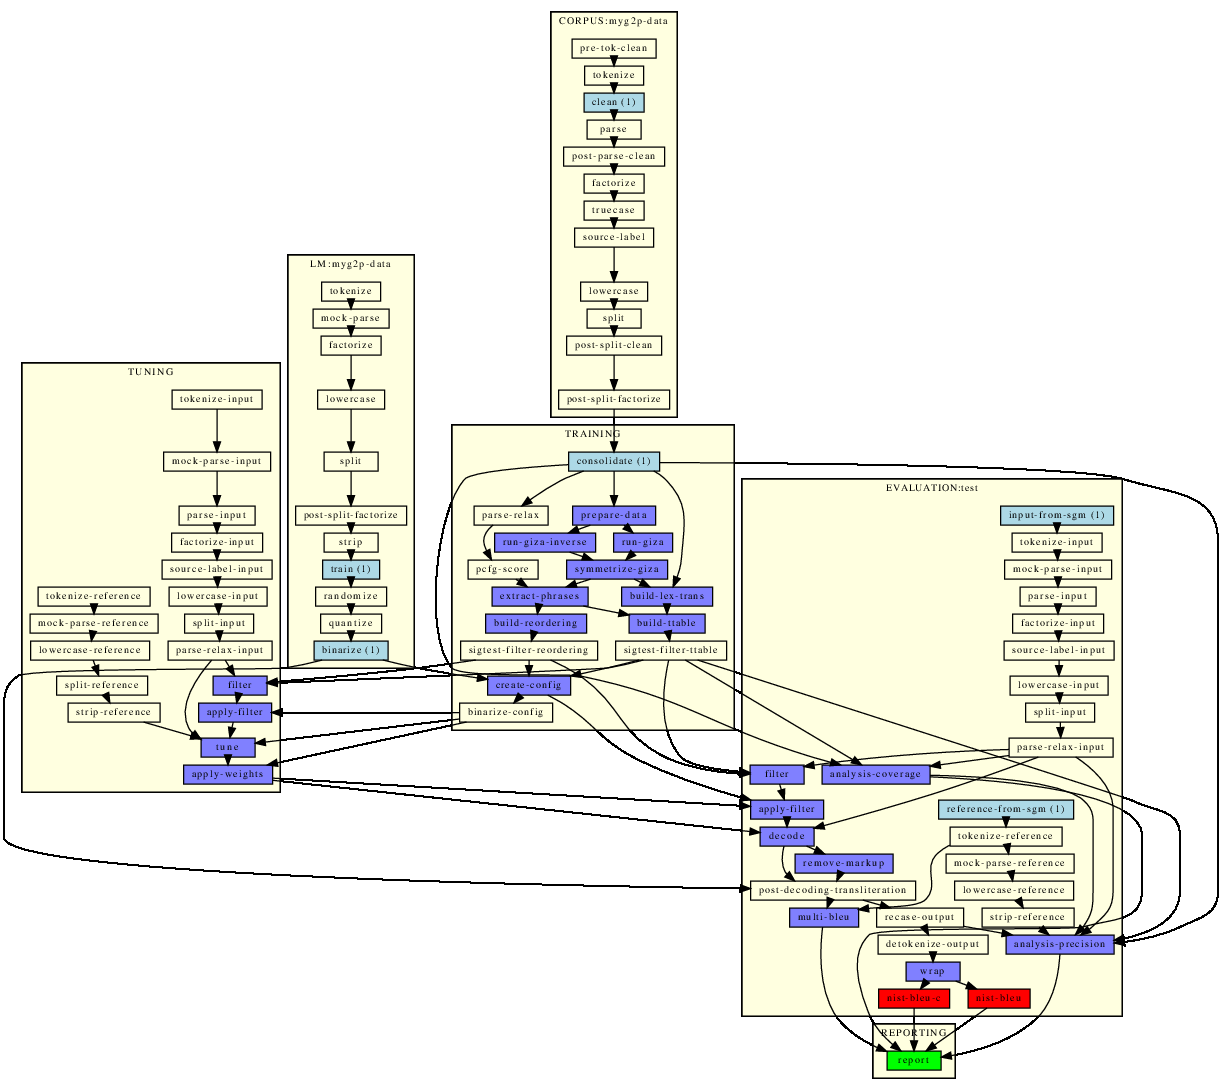

In [20]:
# check graphs
Image(filename=f'{ROOT}/baseline/my-ph/steps/2/graph.2.png', width=800)

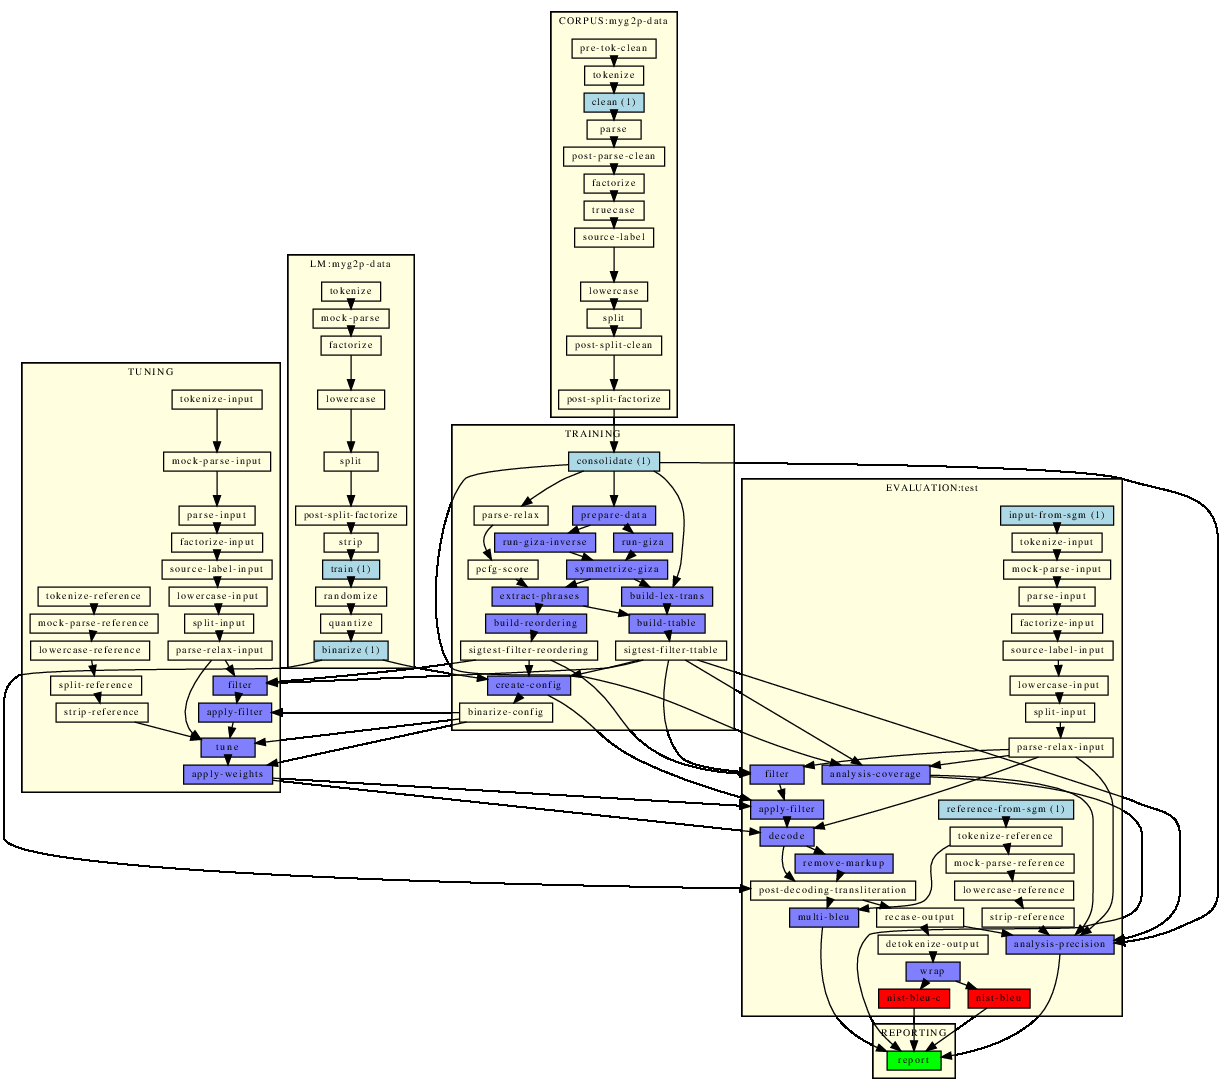

In [21]:
Image(filename=f'{ROOT}/baseline/ph-my/steps/2/graph.2.png', width=800)

## Model Evaluation
### Multi-BLEU Score

In [22]:
# check directory where score evaluation script lives 
!ls {BLEU_DIR} --color=auto

binarize4moses2.perl    generic-parallel.perl  multi-bleu.perl
bsbleu.py               giza-parallel.perl     multi_moses.py
compound-splitter.perl  lopar2pos.pl           ph_numbers.perl
extract-factors.pl      moses-parallel.pl      qsub-wrapper.pl
extract-parallel.perl   moses_sim_pe.py        reverse-alignment.perl
fsa2fsal.pl             mteval-v11b.pl         score-parallel.perl
fsa2plf.pl              mteval-v12.pl          score_parallel.py
fsal2fsa.pl             mteval-v13a.pl         strip-xml.perl
fsa-sample.fsa          mteval-v14.pl          trainlm-irst2.perl


In [23]:
# compute BLEU score with the reference file
!perl {BLEU_DIR}/multi-bleu.perl {DATA_DIR}/test.ph < {DATA_DIR}/seq2seq.myph.hyp.txt | tee {MODEL_DIR}/results/myph_seq2seq_baseline_result.txt

BLEU = 69.49, 85.9/74.0/64.5/57.0 (BP=1.000, ratio=1.000, hyp_len=8044, ref_len=8048)
